# USRP Spectrogram Notebook

This notebook migrates the spectrogram-inspection script into executable cells.

Expected file naming pattern:

`spectrogram_ch<channel>_f<frame>_<timestamp_ms>_<rows>x<cols>.pgm`

- `f<...>` is frame number (not frequency)
- files are binary 8-bit PGM (`P5`)

In [9]:
from pathlib import Path

workspace_root = Path('/home/sat3737/holoscan_demo_workspace/holohub-dev')

notebooks_dir = workspace_root / 'notebooks'

notebooks_dir.mkdir(parents=True, exist_ok=True)

notebook_path = notebooks_dir / 'view_usrp_spectrograms.ipynb'

print(f'notebooks_dir: {notebooks_dir}')

print(f'notebook_path: {notebook_path}')

print(f'exists: {notebook_path.exists()}')

notebooks_dir: /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks
notebook_path: /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks/view_usrp_spectrograms.ipynb
exists: True


In [10]:
# Section 2: Import dependencies and project modules
from pathlib import Path
import re
import json
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Section 3: Move script constants into a parameters cell

SPECTROGRAM_DIR = Path('/tmp/usrp_spectrograms')

MASK_DIR = Path('/tmp/usrp_dino_masks')

CHANNEL_CONFIGS = {

    0: {

        'center_freq_hz': 900e6,

        'sample_rate_hz': 122.88e6,

        'label': 'Channel 0: 900 MHz',

    },

    1: {

        'center_freq_hz': 2450e6,

        'sample_rate_hz': 122.88e6,

        'label': 'Channel 1: 2450 MHz',

    },

}

FFT_SIZE = 20480

SHOW_COLORBAR = True

CHANNEL_TO_PLOT = 1

LATEST_RECORD_COUNT = 5

ACTIVE_CHANNEL = CHANNEL_CONFIGS[CHANNEL_TO_PLOT]

CENTER_FREQ_HZ = ACTIVE_CHANNEL['center_freq_hz']

SAMPLE_RATE_HZ = ACTIVE_CHANNEL['sample_rate_hz']

SPAN_HZ = SAMPLE_RATE_HZ

print(f'SPECTROGRAM_DIR: {SPECTROGRAM_DIR}')

print(f'MASK_DIR: {MASK_DIR}')

print(f'CHANNEL_TO_PLOT: {CHANNEL_TO_PLOT}')

print(f'LATEST_RECORD_COUNT: {LATEST_RECORD_COUNT}')

print(f"Channel label: {ACTIVE_CHANNEL['label']}")

print(f'CENTER_FREQ_HZ: {CENTER_FREQ_HZ/1e6:.3f} MHz')

print(f'SAMPLE_RATE_HZ: {SAMPLE_RATE_HZ/1e6:.3f} Msps')

print(f'SPAN_HZ: {SPAN_HZ/1e6:.3f} MHz')

print(f'FFT_SIZE: {FFT_SIZE}')

SPECTROGRAM_DIR: /tmp/usrp_spectrograms
MASK_DIR: /tmp/usrp_dino_masks
CHANNEL_TO_PLOT: 1
LATEST_RECORD_COUNT: 5
Channel label: Channel 1: 2450 MHz
CENTER_FREQ_HZ: 2450.000 MHz
SAMPLE_RATE_HZ: 122.880 Msps
SPAN_HZ: 122.880 MHz
FFT_SIZE: 20480


In [12]:
# Section 4: Refactor script logic into reusable functions

name_re = re.compile(r'^spectrogram_ch(?P<channel>\d+)_f(?P<frame>\d+)_(?P<ts>\d+)_(?P<rows>\d+)x(?P<cols>\d+)\.pgm$')

mask_re = re.compile(r'^dino_mask_ch(?P<channel>\d+)_f(?P<frame>\d+)_(?P<ts>\d+)_(?P<rows>\d+)x(?P<cols>\d+)\.pgm$')



def read_pgm(path: Path) -> np.ndarray:

    with path.open('rb') as f:

        magic = f.readline().strip()

        if magic != b'P5':

            raise ValueError(f'{path.name}: expected P5, got {magic!r}')



        def next_token_line():

            line = f.readline()

            while line.startswith(b'#'):

                line = f.readline()

            return line



        dims = next_token_line().strip().split()

        if len(dims) != 2:

            raise ValueError(f'{path.name}: invalid dimensions line {dims!r}')

        cols, rows = map(int, dims)

        maxval = int(next_token_line().strip())

        if maxval > 255:

            raise ValueError(f'{path.name}: only 8-bit PGM supported (maxval={maxval})')

        data = f.read(rows * cols)

        if len(data) != rows * cols:

            raise ValueError(f'{path.name}: unexpected payload length {len(data)}')

    return np.frombuffer(data, dtype=np.uint8).reshape(rows, cols)



def parse_metadata(path: Path, pattern: re.Pattern, kind: str) -> dict:

    match = pattern.match(path.name)

    if not match:

        raise ValueError(f'Filename does not match expected format: {path.name}')

    groups = match.groupdict()

    return {

        'path': path,

        'kind': kind,

        'channel': int(groups['channel']),

        'frame': int(groups['frame']),

        'timestamp_ms': int(groups['ts']),

        'rows': int(groups['rows']),

        'cols': int(groups['cols']),

    }



def discover_records(directory: Path, pattern: str, parser: re.Pattern, kind: str):

    files = sorted(directory.glob(pattern))

    records = []

    for path in files:

        try:

            records.append(parse_metadata(path, parser, kind))

        except Exception as exc:

            print(f'Skipping {path.name}: {exc}')

    records = sorted(records, key=lambda record: (record['channel'], record['frame']))

    return files, records



def plot_record(rec: dict, channel_configs=CHANNEL_CONFIGS, show_colorbar=SHOW_COLORBAR):

    img = read_pgm(rec['path'])

    channel_cfg = channel_configs.get(rec['channel'], ACTIVE_CHANNEL)

    center_freq_hz = channel_cfg['center_freq_hz']

    span_hz = channel_cfg['sample_rate_hz']

    f_start = center_freq_hz - span_hz / 2

    f_stop = center_freq_hz + span_hz / 2

    plt.figure(figsize=(10, 4))

    im = plt.imshow(

        img,

        aspect='auto',

        origin='lower',

        extent=[f_start / 1e6, f_stop / 1e6, 0, img.shape[0]],

        cmap='viridis'

    )

    plt.xlabel('Frequency (MHz)')

    plt.ylabel('Time bins (row index)')

    plt.title(

        f"{rec['path'].name} | ch={rec['channel']} frame={rec['frame']} | "

        f"shape={img.shape[0]}x{img.shape[1]} | {channel_cfg['label']}"

    )

    if show_colorbar:

        plt.colorbar(im, label='Normalized intensity (0-255)')

    plt.tight_layout()

    plt.show()

    bins_per_pixel = FFT_SIZE / img.shape[1]

    hz_per_pixel = span_hz / img.shape[1]

    print(f'FFT size: {FFT_SIZE}')

    print(f'Image width: {img.shape[1]} px -> {bins_per_pixel:.2f} FFT bins/pixel')

    print(f'Frequency resolution on plot: {hz_per_pixel/1e3:.2f} kHz/pixel')



def plot_mask_record(rec: dict):

    img = read_pgm(rec['path'])

    plt.figure(figsize=(10, 4))

    plt.imshow(img, aspect='auto', origin='lower', cmap='gray', vmin=0, vmax=255)

    plt.xlabel('Frequency bins')

    plt.ylabel('Time bins')

    plt.title(f"{rec['path'].name} | ch={rec['channel']} frame={rec['frame']} | shape={img.shape[0]}x{img.shape[1]}")

    plt.tight_layout()

    plt.show()

    print(f'Mask foreground pixels: {(img > 0).sum()} / {img.size}')

In [13]:
# Section 5: Run the main workflow step by step

all_spectrogram_files, all_spectrogram_records = discover_records(

    SPECTROGRAM_DIR,

    'spectrogram_ch*_f*_*.pgm',

    name_re,

    'spectrogram',

)

all_mask_files, all_mask_records = discover_records(

    MASK_DIR,

    'dino_mask_ch*_f*_*.pgm',

    mask_re,

    'mask',

)

spectrogram_records = sorted(all_spectrogram_records, key=lambda r: r['timestamp_ms'])[-LATEST_RECORD_COUNT:]

mask_records = sorted(all_mask_records, key=lambda r: r['timestamp_ms'])[-LATEST_RECORD_COUNT:]

spectrogram_files = [r['path'] for r in spectrogram_records]

mask_files = [r['path'] for r in mask_records]

print(f'Found {len(all_spectrogram_files)} total spectrogram file(s); using newest {len(spectrogram_records)} record(s).')

print(f'Found {len(all_mask_files)} total mask file(s); using newest {len(mask_records)} record(s).')

if spectrogram_records:

    print('Newest spectrogram records:')

    for rec in spectrogram_records:

        print(f"  {rec['path'].name} -> ch={rec['channel']} frame={rec['frame']} rows={rec['rows']} cols={rec['cols']}")

else:

    print('No matching spectrogram records found.')

if mask_records:

    print('Newest mask records:')

    for rec in mask_records:

        print(f"  {rec['path'].name} -> ch={rec['channel']} frame={rec['frame']} rows={rec['rows']} cols={rec['cols']}")

else:

    print('No matching mask records found.')

Found 26 total spectrogram file(s); using newest 5 record(s).
Found 15 total mask file(s); using newest 5 record(s).
Newest spectrogram records:
  spectrogram_ch1_f1_1775151030945_250x512.pgm -> ch=1 frame=1 rows=250 cols=512
  spectrogram_ch1_f2_1775151030998_250x512.pgm -> ch=1 frame=2 rows=250 cols=512
  spectrogram_ch1_f3_1775151031050_250x512.pgm -> ch=1 frame=3 rows=250 cols=512
  spectrogram_ch1_f4_1775151031103_250x512.pgm -> ch=1 frame=4 rows=250 cols=512
  spectrogram_ch1_f5_1775151031159_250x512.pgm -> ch=1 frame=5 rows=250 cols=512
Newest mask records:
  dino_mask_ch1_f1_1775151030950_256x512.pgm -> ch=1 frame=1 rows=256 cols=512
  dino_mask_ch1_f2_1775151031000_256x512.pgm -> ch=1 frame=2 rows=256 cols=512
  dino_mask_ch1_f3_1775151031052_256x512.pgm -> ch=1 frame=3 rows=256 cols=512
  dino_mask_ch1_f4_1775151031105_256x512.pgm -> ch=1 frame=4 rows=256 cols=512
  dino_mask_ch1_f5_1775151031162_256x512.pgm -> ch=1 frame=5 rows=256 cols=512


Spectrogram shapes in newest window: [(250, 512)]
Spectrogram channels present in newest window: [1]
Spectrogram frame range in newest window: 1 -> 5

Plotting 5 spectrogram(s) for channel 1 from newest window:


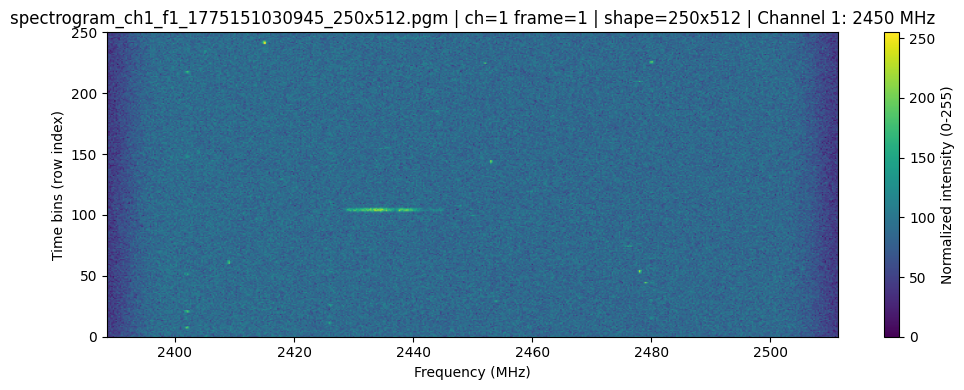

FFT size: 20480
Image width: 512 px -> 40.00 FFT bins/pixel
Frequency resolution on plot: 240.00 kHz/pixel


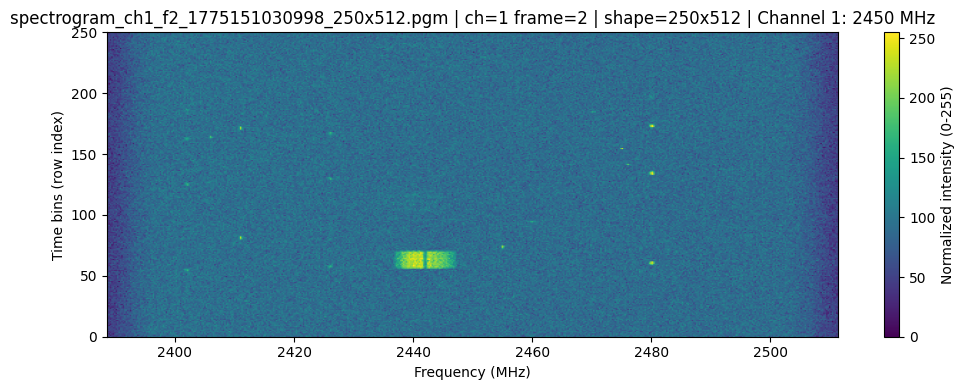

FFT size: 20480
Image width: 512 px -> 40.00 FFT bins/pixel
Frequency resolution on plot: 240.00 kHz/pixel


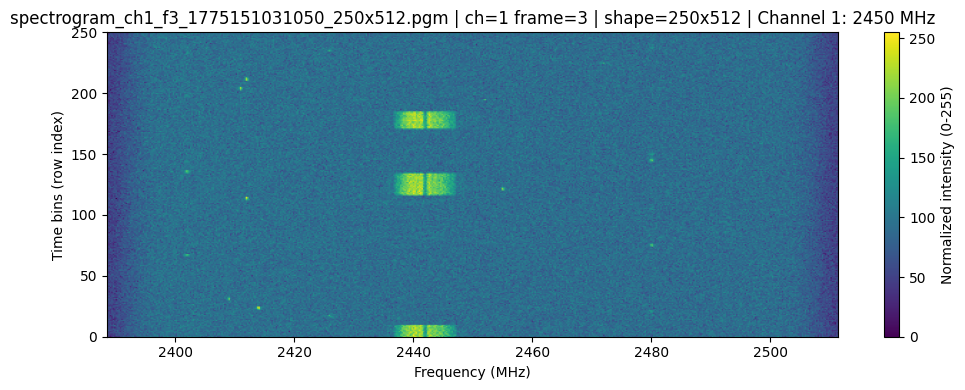

FFT size: 20480
Image width: 512 px -> 40.00 FFT bins/pixel
Frequency resolution on plot: 240.00 kHz/pixel


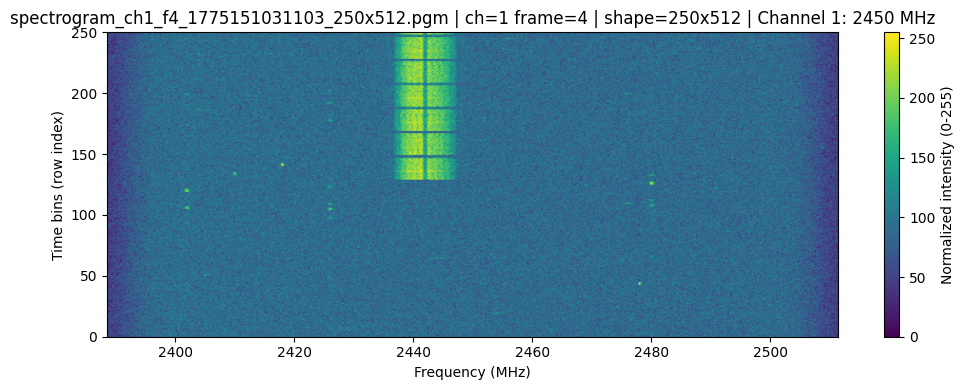

FFT size: 20480
Image width: 512 px -> 40.00 FFT bins/pixel
Frequency resolution on plot: 240.00 kHz/pixel


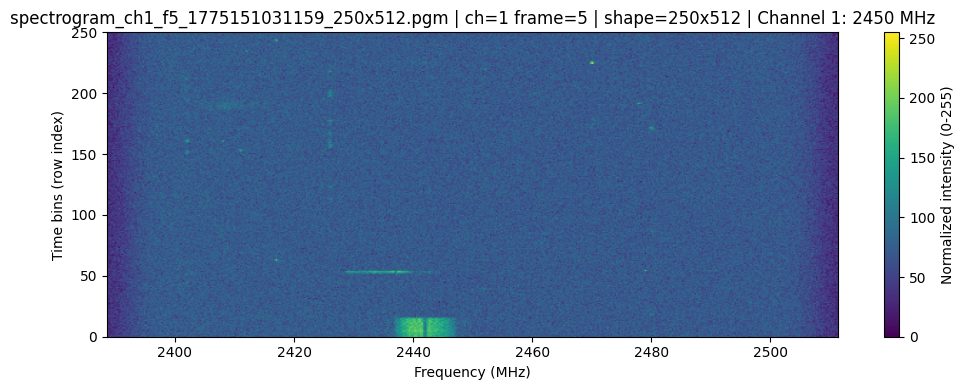

FFT size: 20480
Image width: 512 px -> 40.00 FFT bins/pixel
Frequency resolution on plot: 240.00 kHz/pixel
Files for channel 1 in newest window: 5

Mask shapes in newest window: [(256, 512)]
Mask channels present in newest window: [1]

Plotting 5 mask(s) for channel 1 from newest window:


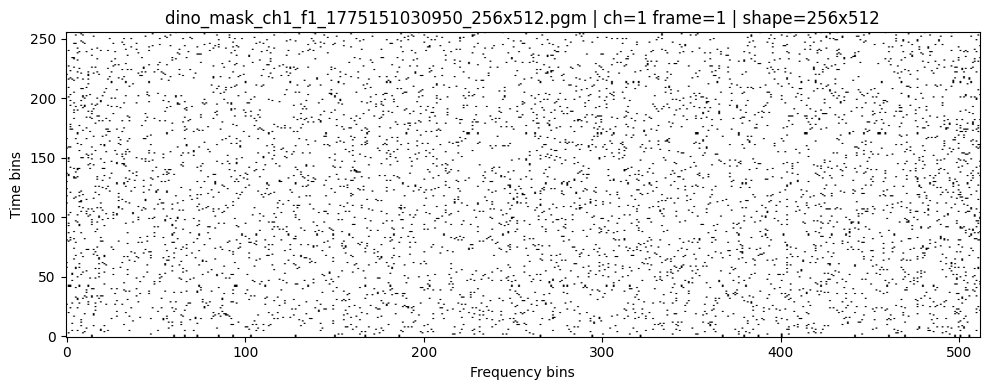

Mask foreground pixels: 125739 / 131072


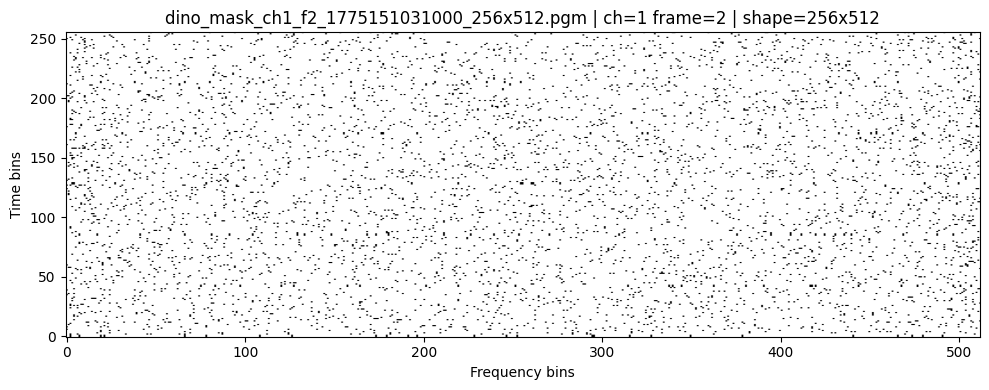

Mask foreground pixels: 125802 / 131072


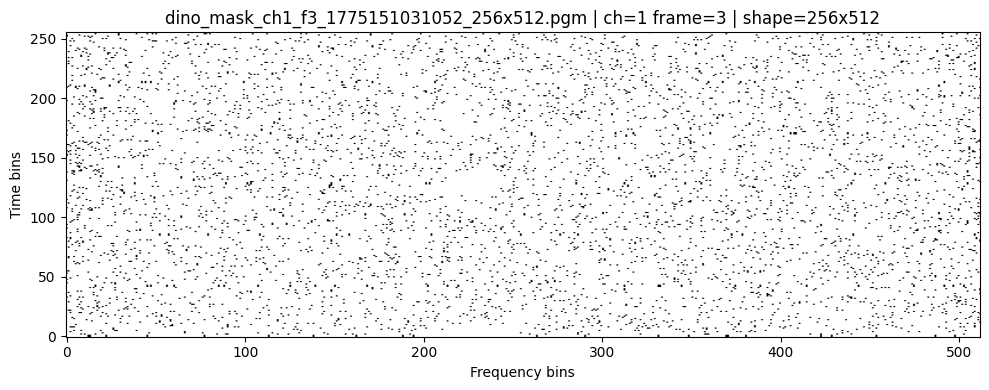

Mask foreground pixels: 125795 / 131072


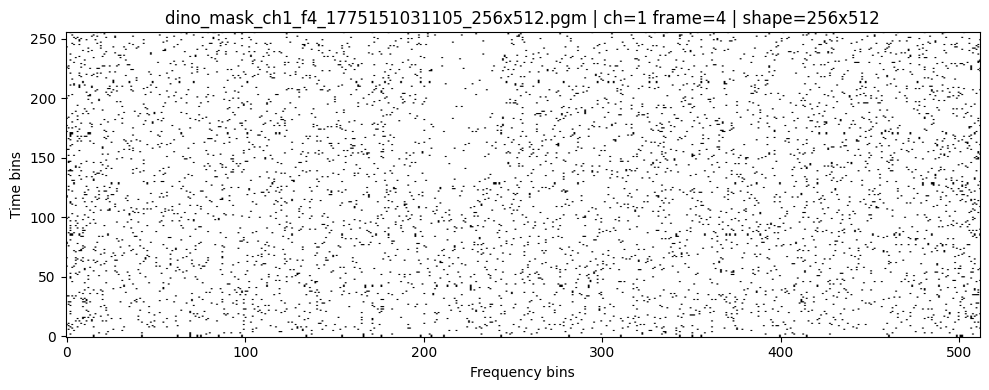

Mask foreground pixels: 125933 / 131072


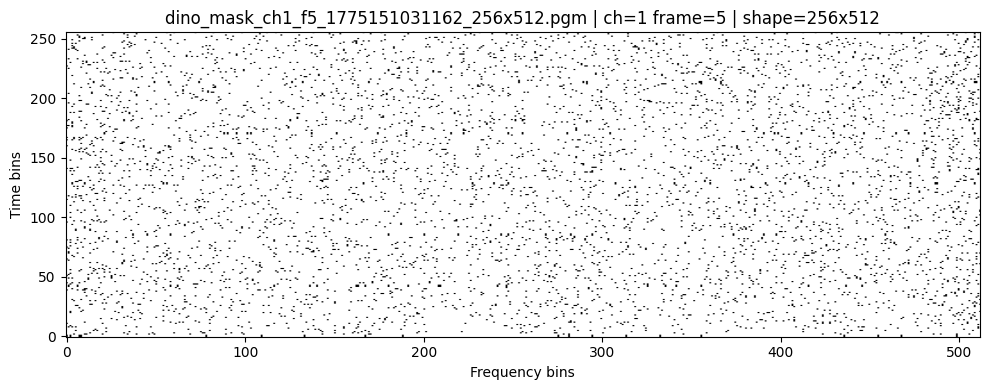

Mask foreground pixels: 125713 / 131072
Masks for channel 1 in newest window: 5


In [14]:
# Section 6: Display results and key diagnostics

channel_spectrograms = [r for r in spectrogram_records if r['channel'] == CHANNEL_TO_PLOT]

channel_masks = [r for r in mask_records if r['channel'] == CHANNEL_TO_PLOT]

if spectrogram_records:

    uniq_shapes = sorted({(r['rows'], r['cols']) for r in spectrogram_records})

    channels = sorted({r['channel'] for r in spectrogram_records})

    frames = [r['frame'] for r in spectrogram_records]

    print(f'Spectrogram shapes in newest window: {uniq_shapes}')

    print(f'Spectrogram channels present in newest window: {channels}')

    print(f'Spectrogram frame range in newest window: {min(frames)} -> {max(frames)}')

    if channel_spectrograms:

        print(f'\nPlotting {len(channel_spectrograms)} spectrogram(s) for channel {CHANNEL_TO_PLOT} from newest window:')

        for rec in channel_spectrograms:

            plot_record(rec)

        print(f'Files for channel {CHANNEL_TO_PLOT} in newest window: {len(channel_spectrograms)}')

    else:

        print(f'No spectrograms found for channel {CHANNEL_TO_PLOT} in newest window.')

else:

    print('No spectrogram records available for plotting.')

if mask_records:

    mask_shapes = sorted({(r['rows'], r['cols']) for r in mask_records})

    mask_channels = sorted({r['channel'] for r in mask_records})

    print(f'\nMask shapes in newest window: {mask_shapes}')

    print(f'Mask channels present in newest window: {mask_channels}')

    if channel_masks:

        print(f'\nPlotting {len(channel_masks)} mask(s) for channel {CHANNEL_TO_PLOT} from newest window:')

        for rec in channel_masks:

            plot_mask_record(rec)

        print(f'Masks for channel {CHANNEL_TO_PLOT} in newest window: {len(channel_masks)}')

    else:

        print(f'No masks found for channel {CHANNEL_TO_PLOT} in newest window.')

else:

    print('No mask records available for plotting.')

In [15]:
# Section 7: Add a quick validation/test cell

if spectrogram_records:

    sample = spectrogram_records[-1]

    img = read_pgm(sample['path'])

    assert img.ndim == 2, 'Image must be 2D'

    assert img.dtype == np.uint8, 'Image dtype must be uint8'

    assert img.shape == (sample['rows'], sample['cols']), 'Image shape must match filename metadata'

    assert img.min() >= 0 and img.max() <= 255, 'Pixel range must be [0, 255]'

    print('Spectrogram validation checks passed')

    print(f"Sample: {sample['path'].name}, shape={img.shape}, min={img.min()}, max={img.max()}")

else:

    print('No spectrogram records found; spectrogram validation skipped.')

if mask_records:

    mask_sample = mask_records[-1]

    mask_img = read_pgm(mask_sample['path'])

    assert mask_img.ndim == 2, 'Mask image must be 2D'

    assert mask_img.dtype == np.uint8, 'Mask image dtype must be uint8'

    assert mask_img.shape == (mask_sample['rows'], mask_sample['cols']), 'Mask shape must match filename metadata'

    print('Mask validation checks passed')

    print(f"Mask sample: {mask_sample['path'].name}, shape={mask_img.shape}, foreground={(mask_img > 0).sum()}")

else:

    print('No mask records found; mask validation skipped.')

Spectrogram validation checks passed
Sample: spectrogram_ch1_f5_1775151031159_250x512.pgm, shape=(250, 512), min=0, max=255
Mask validation checks passed
Mask sample: dino_mask_ch1_f5_1775151031162_256x512.pgm, shape=(256, 512), foreground=125713


In [16]:
# Section 8: Export artifacts and save outputs

summary_path = SPECTROGRAM_DIR / 'spectrogram_summary.json'

summary = {

    'spectrogram_dir': str(SPECTROGRAM_DIR),

    'mask_dir': str(MASK_DIR),

    'latest_record_count': LATEST_RECORD_COUNT,

    'num_spectrogram_files_total': len(all_spectrogram_files) if 'all_spectrogram_files' in globals() else 0,

    'num_spectrogram_records': len(spectrogram_records) if 'spectrogram_records' in globals() else 0,

    'num_mask_files_total': len(all_mask_files) if 'all_mask_files' in globals() else 0,

    'num_mask_records': len(mask_records) if 'mask_records' in globals() else 0,

    'channel_to_plot': CHANNEL_TO_PLOT,

    'channel_configs': CHANNEL_CONFIGS,

    'fft_size': FFT_SIZE,

}

if 'spectrogram_records' in globals() and spectrogram_records:

    summary['spectrogram_channels'] = sorted({r['channel'] for r in spectrogram_records})

    summary['spectrogram_shapes'] = sorted({(r['rows'], r['cols']) for r in spectrogram_records})

    summary['first_spectrogram_file'] = spectrogram_records[0]['path'].name

    summary['last_spectrogram_file'] = spectrogram_records[-1]['path'].name

if 'mask_records' in globals() and mask_records:

    summary['mask_channels'] = sorted({r['channel'] for r in mask_records})

    summary['mask_shapes'] = sorted({(r['rows'], r['cols']) for r in mask_records})

    summary['first_mask_file'] = mask_records[0]['path'].name

    summary['last_mask_file'] = mask_records[-1]['path'].name

with summary_path.open('w', encoding='utf-8') as f:

    json.dump(summary, f, indent=2)

print(f'Wrote summary to: {summary_path}')

print(json.dumps(summary, indent=2))

Wrote summary to: /tmp/usrp_spectrograms/spectrogram_summary.json
{
  "spectrogram_dir": "/tmp/usrp_spectrograms",
  "mask_dir": "/tmp/usrp_dino_masks",
  "latest_record_count": 5,
  "num_spectrogram_files_total": 26,
  "num_spectrogram_records": 5,
  "num_mask_files_total": 15,
  "num_mask_records": 5,
  "channel_to_plot": 1,
  "channel_configs": {
    "0": {
      "center_freq_hz": 900000000.0,
      "sample_rate_hz": 122880000.0,
      "label": "Channel 0: 900 MHz"
    },
    "1": {
      "center_freq_hz": 2450000000.0,
      "sample_rate_hz": 122880000.0,
      "label": "Channel 1: 2450 MHz"
    }
  },
  "fft_size": 20480,
  "spectrogram_channels": [
    1
  ],
  "spectrogram_shapes": [
    [
      250,
      512
    ]
  ],
  "first_spectrogram_file": "spectrogram_ch1_f1_1775151030945_250x512.pgm",
  "last_spectrogram_file": "spectrogram_ch1_f5_1775151031159_250x512.pgm",
  "mask_channels": [
    1
  ],
  "mask_shapes": [
    [
      256,
      512
    ]
  ],
  "first_mask_file": "